데이터 파일(.csv, .xlsx, .xls)을 업로드 해주세요.


Saving 자유로 주행차량의 과속으로 인한 사고 예측.xlsx to 자유로 주행차량의 과속으로 인한 사고 예측.xlsx
데이터 로딩 완료: 자유로 주행차량의 과속으로 인한 사고 예측.xlsx (형태: (18, 6))


,항목,주행차량수,과속차량수,날씨지수,도로상태지수,사고발생횟수
0,2021년 1월,1200,150,7.5,8.0,10
1,2021년 2월,1300,160,6.0,7.5,12
2,2021년 3월,1250,170,6.5,8.2,13
3,2021년 4월,1350,180,7.0,8.5,15
4,2021년 5월,1400,200,8.0,9.0,18


시간 컬럼: 항목, 예측 타겟: 사고발생횟수
학습 데이터 크기: (6, 10, 1), 검증 데이터 크기: (2, 10, 1)
Epoch 1/100


/tmp/ipykernel_2960/444597772.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[time_col] = pd.to_datetime(df[time_col])
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.3959 - mae: 0.6050 - val_loss: 0.7693 - val_mae: 0.8765
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.3502 - mae: 0.5670 - val_loss: 0.6869 - val_mae: 0.8283
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.3087 - mae: 0.5303 - val_loss: 0.6087 - val_mae: 0.7797
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.2700 - mae: 0.4936 - val_loss: 0.5392 - val_mae: 0.7338
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.2373 - mae: 0.4606 - val_loss: 0.4754 - val_mae: 0.6891
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.2063 - mae: 0.4268 - val_loss: 0.4142 - val_mae: 0.6432
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.1780 - mae: 0.3936 - val_loss: 0.3613 - val_mae: 0.6007
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.1540 - mae: 0.3633 - val_loss: 0.3135 - val_mae: 0.5596
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.1312 - mae: 0.3318 - val_

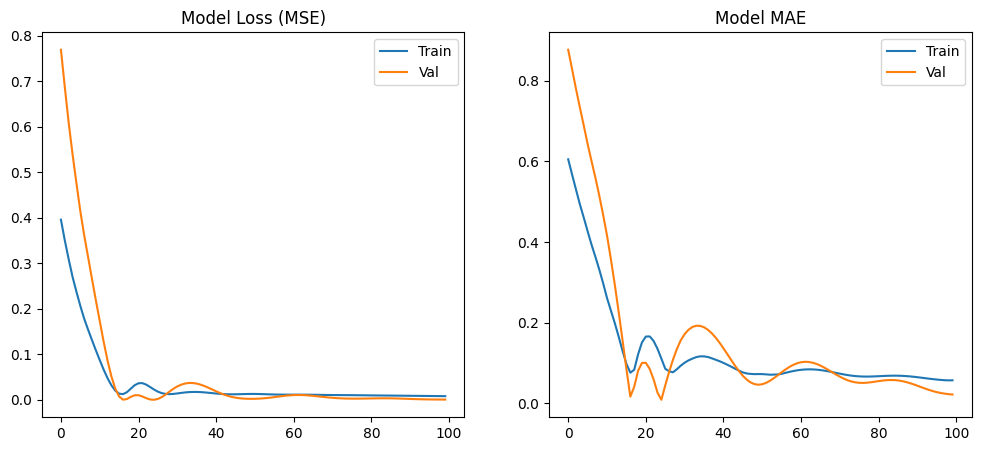

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


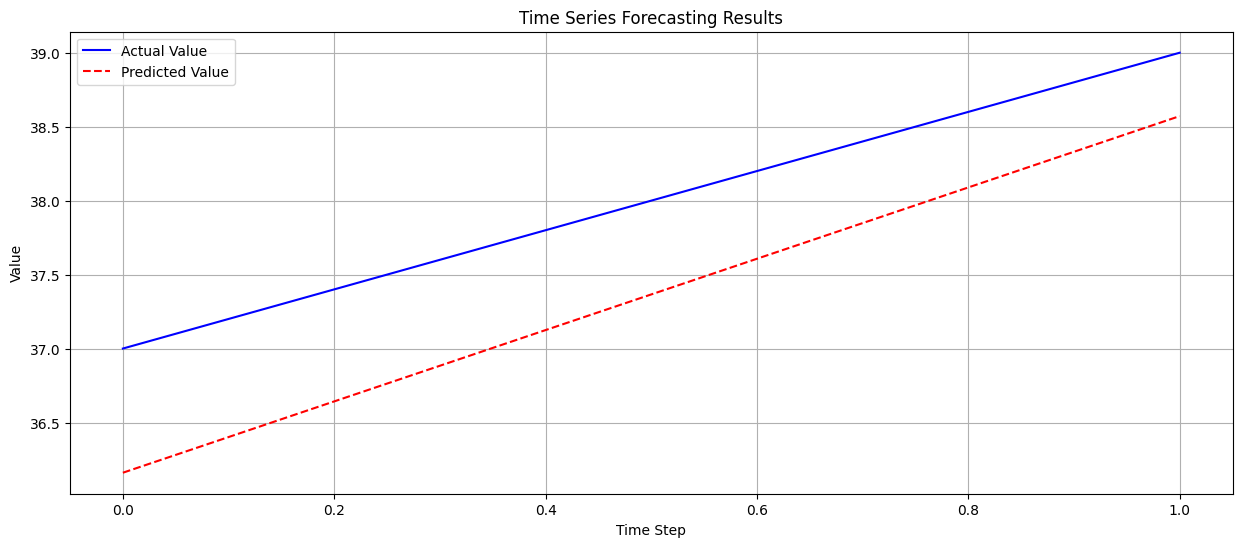

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,029 (222.77 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 38,020 (148.52 KB)

In [18]:
# ==========================================
# 1. 파일 업로드 및 데이터 로드 (Colab 환경)
# ==========================================
from google.colab import files
import os
import pandas as pd

print("데이터 파일(.csv, .xlsx, .xls)을 업로드 해주세요.")
uploaded = files.upload()

if len(uploaded.keys()) == 0:
    # 업로드된 파일이 없을 경우 예시 파일명
    DATA_FILE_PATH = "data.csv"
    print(f"업로드된 파일이 없습니다. 기본 파일명을 사용합니다: {DATA_FILE_PATH}")
else:
    DATA_FILE_PATH = list(uploaded.keys())[0]

if DATA_FILE_PATH.endswith('.csv'):
    df = pd.read_csv(DATA_FILE_PATH)
elif DATA_FILE_PATH.endswith(('.xls', '.xlsx')):
    df = pd.read_excel(DATA_FILE_PATH)
else:
    print("지원하지 않는 파일 형식입니다.")

print(f"데이터 로딩 완료: {DATA_FILE_PATH} (형태: {df.shape})")

# ==========================================
# 2. 라이브러리 임포트
# ==========================================
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# 3. 데이터 탐색 및 전처리 (시계열 특징 추출)
# ==========================================
# 결측치 제거
df = df.dropna()
display(df.head())

# 첫 컬럼=시간(Index), 마지막 컬럼=타겟으로 가정
time_col = df.columns[0]
target_col = df.columns[-1]
print(f"시간 컬럼: {time_col}, 예측 타겟: {target_col}")

# 시간 순서 정렬
try:
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(time_col)
except:
    pass

# 타겟 데이터 추출 및 정규화 (MinMax)
target_values = df[[target_col]].values.astype('float32')
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(target_values)

# ==========================================
# 4. 시퀀스 데이터 생성 (과거 데이터를 기반으로 미래 예측)
# ==========================================
SEQ_LENGTH = 10 # 과거 10개의 데이터를 보고 다음 1개를 예측
x_seq, y_seq = [], []

for i in range(len(scaled_data) - SEQ_LENGTH):
    x_seq.append(scaled_data[i : i + SEQ_LENGTH])
    y_seq.append(scaled_data[i + SEQ_LENGTH])

x_seq = np.array(x_seq)
y_seq = np.array(y_seq)

# ==========================================
# 5. 데이터를 training set과 validation set으로 나누기
# ==========================================
# 시계열 데이터이므로 섞지 않고 순서대로 분할
split_idx = int(len(x_seq) * 0.8)

x_train, x_val = x_seq[:split_idx], x_seq[split_idx:]
y_train, y_val = y_seq[:split_idx], y_seq[split_idx:]

print(f"학습 데이터 크기: {x_train.shape}, 검증 데이터 크기: {x_val.shape}")

# ==========================================
# 6. 모델 생성 (LSTM)
# ==========================================
model = tf.keras.Sequential()
model.add(LSTM(64, input_shape=(SEQ_LENGTH, 1), return_sequences=False, activation='tanh'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1)) # 다음 시점의 값 1개 예측

# ==========================================
# 7. 모델 설정 및 학습
# ==========================================
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# 모델 학습
history = model.fit(x_train, y_train, validation_data=(x_val, y_val), batch_size=16, epochs=100)

# ==========================================
# 8. 모델 결과 확인 (그래프)
# ==========================================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss (MSE)')
plt.legend(['Train', 'Val'])

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('Model MAE')
plt.legend(['Train', 'Val'])
plt.show()

# ==========================================
# 9. 테스트 및 시각화 (예측 결과 비교)
# ==========================================
# 검증 데이터 예측
y_pred_scaled = model.predict(x_val)

# 역정규화 (원래 스케일로 복원)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_val_actual = scaler.inverse_transform(y_val)

plt.figure(figsize=(15, 6))
plt.plot(y_val_actual, label='Actual Value', color='blue')
plt.plot(y_pred, label='Predicted Value', color='red', linestyle='--')
plt.title('Time Series Forecasting Results')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# 10. 모델 저장 및 불러오기
# ==========================================
model.save('timeseries_forecasting_model.keras')

model_loaded = tf.keras.models.load_model('timeseries_forecasting_model.keras')
model_loaded.summary()